<a href="https://colab.research.google.com/github/TamirPalay/DI_Exercises/blob/main/week14/day1-2/Text_Analysis_Daily.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# --- Imports ---
import requests
import re
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk import pos_tag, ne_chunk

import spacy
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# --- One-time NLTK resource downloads (same ones the tutorials used) ---
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')  # for pos_tag
nltk.download('maxent_ne_chunker')               # for ne_chunk
nltk.download('maxent_ne_chunker_tab')
nltk.download('words')

# --- spaCy model: run the download line ONCE, then load ---
# In its own cell:  !python -m spacy download en_core_web_sm
nlp = spacy.load('en_core_web_sm')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker is already up-to-date!
[nltk_data] Downloading package maxent_ne_chunker_tab to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package maxent_ne_chunker_tab is already up-to-date!
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [5]:
import requests
import re

URLS = [
    'https://www.gutenberg.org/cache/epub/11/pg11.txt',       # Alice's Adventures in Wonderland
    'https://www.gutenberg.org/cache/epub/12/pg12.txt',       # Through the Looking-Glass
    'https://www.gutenberg.org/cache/epub/29042/pg29042.txt', # A Tangled Tale
]

# Gutenberg wraps every book between these two marker lines.
# We slice BETWEEN them to drop the license header/footer.
START_TAG = '*** START OF THE PROJECT GUTENBERG EBOOK'
END_TAG   = '*** END OF THE PROJECT GUTENBERG EBOOK'


def load_texts(urls):
    corpus = []
    for url in urls:
        # 1. Download the raw text
        raw = requests.get(url).text

        # 2. Trim the Gutenberg boilerplate (do this while newlines still exist)
        start = raw.find(START_TAG)
        end   = raw.find(END_TAG)

        if start != -1 and end != -1 and start < end:
            start = raw.find('\n', start)   # jump to the END of the start-marker line
            body  = raw[start:end]          # stops right BEFORE the end-marker line
        else:
            # Marker(s) not found as expected -> keep the whole text, warn so you notice
            print(f'⚠️  Markers not found for {url} — using full text')
            body = raw

        # 3. Clean non-word characters with regex
        #    \W  -> replace every non-word char (punctuation, newlines...) with a SPACE
        #    \s+ -> collapse the resulting runs of whitespace into a single space
        text = re.sub(r'\W', ' ', body)
        text = re.sub(r'\s+', ' ', text).strip()

        # 4. Append the cleaned book to the corpus
        corpus.append(text)

    return corpus


corpus = load_texts(URLS)
print(f'{len(corpus)} documents loaded\n')

# Sanity check both ends this time:
for i, text in enumerate(corpus):
    print(f'--- Text {i} (first 200 chars) ---')
    print(text[:500])
    print(f'--- Text {i} (last 200 chars) ---')
    print(text[-200:])
    print()

3 documents loaded

--- Text 0 (first 200 chars) ---
Illustration Alice s Adventures in Wonderland by Lewis Carroll THE MILLENNIUM FULCRUM EDITION 3 0 Contents CHAPTER I Down the Rabbit Hole CHAPTER II The Pool of Tears CHAPTER III A Caucus Race and a Long Tale CHAPTER IV The Rabbit Sends in a Little Bill CHAPTER V Advice from a Caterpillar CHAPTER VI Pig and Pepper CHAPTER VII A Mad Tea Party CHAPTER VIII The Queen s Croquet Ground CHAPTER IX The Mock Turtle s Story CHAPTER X The Lobster Quadrille CHAPTER XI Who Stole the Tarts CHAPTER XII Alice 
--- Text 0 (last 200 chars) ---
h the dream of Wonderland of long ago and how she would feel with all their simple sorrows and find a pleasure in all their simple joys remembering her own child life and the happy summer days THE END

--- Text 1 (first 200 chars) ---
Illustration THROUGH THE LOOKING GLASS And What Alice Found There By Lewis Carroll The Millennium Fulcrum Edition 1 7 DRAMATIS PERSONÆ _As arranged before commencement of game _ W

In [9]:
# Map each book index -> a unique phrase where its real story begins.
# Leave a value as '' to skip trimming that book.
CONTENT_START = {
    0: 'Alice was beginning to get very tired',   # Alice in Wonderland  (verified)
    1: 'One thing was certain',   # Through the Looking-Glass — fill from your output
    2: 'The ruddy glow of sunset was already fading into the sombre shadows of night',   # A Tangled Tale        — fill from your output
}

for i, phrase in CONTENT_START.items():
    if not phrase:
        continue
    pos = corpus[i].find(phrase)
    if pos != -1:
        corpus[i] = corpus[i][pos:]           # drop everything before the story
    else:
        print(f'⚠️  Phrase not found in Text {i} — left untrimmed. Check spacing/casing.')

print('Front-matter trim applied.')

Front-matter trim applied.


In [10]:
for i, text in enumerate(corpus):
    print(f'--- Text {i} (first 200 chars) ---')
    print(text[:200])
    print()

--- Text 0 (first 200 chars) ---
Alice was beginning to get very tired of sitting by her sister on the bank and of having nothing to do once or twice she had peeped into the book her sister was reading but it had no pictures or conve

--- Text 1 (first 200 chars) ---
One thing was certain that the _white_ kitten had had nothing to do with it it was the black kitten s fault entirely For the white kitten had been having its face washed by the old cat for the last qu

--- Text 2 (first 200 chars) ---
The ruddy glow of sunset was already fading into the sombre shadows of night when two travellers might have been observed swiftly at a pace of six miles in the hour descending the rugged side of a mou



In [11]:
tokenized_books = []
for text in corpus:
    tokens = word_tokenize(text)
    tokenized_books.append(tokens)
    print(tokens[:150])
    print('\n---\n')

['Alice', 'was', 'beginning', 'to', 'get', 'very', 'tired', 'of', 'sitting', 'by', 'her', 'sister', 'on', 'the', 'bank', 'and', 'of', 'having', 'nothing', 'to', 'do', 'once', 'or', 'twice', 'she', 'had', 'peeped', 'into', 'the', 'book', 'her', 'sister', 'was', 'reading', 'but', 'it', 'had', 'no', 'pictures', 'or', 'conversations', 'in', 'it', 'and', 'what', 'is', 'the', 'use', 'of', 'a', 'book', 'thought', 'Alice', 'without', 'pictures', 'or', 'conversations', 'So', 'she', 'was', 'considering', 'in', 'her', 'own', 'mind', 'as', 'well', 'as', 'she', 'could', 'for', 'the', 'hot', 'day', 'made', 'her', 'feel', 'very', 'sleepy', 'and', 'stupid', 'whether', 'the', 'pleasure', 'of', 'making', 'a', 'daisy', 'chain', 'would', 'be', 'worth', 'the', 'trouble', 'of', 'getting', 'up', 'and', 'picking', 'the', 'daisies', 'when', 'suddenly', 'a', 'White', 'Rabbit', 'with', 'pink', 'eyes', 'ran', 'close', 'by', 'her', 'There', 'was', 'nothing', 'so', '_very_', 'remarkable', 'in', 'that', 'nor', 'did'

In [12]:
stop_words = set(stopwords.words('english'))  # set = O(1) lookups, much faster on big books

filtered_books = []
for tokens in tokenized_books:
    # TODO: keep a token only if its LOWERCASE form is not a stopword
    # hint: [w for w in tokens if w.lower() not in stop_words]
    filtered_tokens = [w for w in tokens if w.lower() not in stop_words]
    filtered_books.append(filtered_tokens)
    print(filtered_tokens[:150])
    print('\n---\n')

# Verify removal — these should now be ~0:
print(filtered_books[0].count('i'), filtered_books[0].count('me'), filtered_books[0].count('my'))

['Alice', 'beginning', 'get', 'tired', 'sitting', 'sister', 'bank', 'nothing', 'twice', 'peeped', 'book', 'sister', 'reading', 'pictures', 'conversations', 'use', 'book', 'thought', 'Alice', 'without', 'pictures', 'conversations', 'considering', 'mind', 'well', 'could', 'hot', 'day', 'made', 'feel', 'sleepy', 'stupid', 'whether', 'pleasure', 'making', 'daisy', 'chain', 'would', 'worth', 'trouble', 'getting', 'picking', 'daisies', 'suddenly', 'White', 'Rabbit', 'pink', 'eyes', 'ran', 'close', 'nothing', '_very_', 'remarkable', 'Alice', 'think', '_very_', 'much', 'way', 'hear', 'Rabbit', 'say', 'Oh', 'dear', 'Oh', 'dear', 'shall', 'late', 'thought', 'afterwards', 'occurred', 'ought', 'wondered', 'time', 'seemed', 'quite', 'natural', 'Rabbit', 'actually', '_took', 'watch', 'waistcoat', 'pocket_', 'looked', 'hurried', 'Alice', 'started', 'feet', 'flashed', 'across', 'mind', 'never', 'seen', 'rabbit', 'either', 'waistcoat', 'pocket', 'watch', 'take', 'burning', 'curiosity', 'ran', 'across',

In [13]:
stemmer = PorterStemmer()
stemmed = [stemmer.stem(w) for w in filtered_books[0]]
print(stemmed[:50])

['alic', 'begin', 'get', 'tire', 'sit', 'sister', 'bank', 'noth', 'twice', 'peep', 'book', 'sister', 'read', 'pictur', 'convers', 'use', 'book', 'thought', 'alic', 'without', 'pictur', 'convers', 'consid', 'mind', 'well', 'could', 'hot', 'day', 'made', 'feel', 'sleepi', 'stupid', 'whether', 'pleasur', 'make', 'daisi', 'chain', 'would', 'worth', 'troubl', 'get', 'pick', 'daisi', 'suddenli', 'white', 'rabbit', 'pink', 'eye', 'ran', 'close']


In [14]:
# spaCy likes CONTEXT, so feed it a string rather than isolated tokens.
text_for_spacy = ' '.join(filtered_books[0])

# spaCy has a default ~1,000,000-char cap. If you hit an error, bump it:
# nlp.max_length = len(text_for_spacy) + 100

# Speed tip: lemmas don't need the parser/NER, so you can disable them:
# doc = nlp(text_for_spacy, disable=['parser', 'ner'])
doc = nlp(text_for_spacy)

# HINT from the instructions: the lemma is an ATTRIBUTE -> token.lemma_
lemmatized = [token.lemma_ for token in doc]
print(lemmatized[:50])

['Alice', 'beginning', 'get', 'tired', 'sit', 'sister', 'bank', 'nothing', 'twice', 'peep', 'book', 'sister', 'read', 'picture', 'conversation', 'use', 'book', 'think', 'Alice', 'without', 'picture', 'conversation', 'consider', 'mind', 'well', 'could', 'hot', 'day', 'make', 'feel', 'sleepy', 'stupid', 'whether', 'pleasure', 'make', 'daisy', 'chain', 'would', 'worth', 'trouble', 'getting', 'pick', 'daisy', 'suddenly', 'White', 'Rabbit', 'pink', 'eye', 'run', 'close']


## Stemming vs lemmatization

Stemmer produced more non words. Lemmatised used more real words.

In [15]:
# Tip: POS tagging is more accurate WITH grammatical context, so tagging the
# pre-stopword-removal tokens (tokenized_books) often gives better tags.
tagged = pos_tag(tokenized_books[0])
print(tagged[:30])

[('Alice', 'NNP'), ('was', 'VBD'), ('beginning', 'VBG'), ('to', 'TO'), ('get', 'VB'), ('very', 'RB'), ('tired', 'JJ'), ('of', 'IN'), ('sitting', 'VBG'), ('by', 'IN'), ('her', 'PRP$'), ('sister', 'NN'), ('on', 'IN'), ('the', 'DT'), ('bank', 'NN'), ('and', 'CC'), ('of', 'IN'), ('having', 'VBG'), ('nothing', 'NN'), ('to', 'TO'), ('do', 'VB'), ('once', 'RB'), ('or', 'CC'), ('twice', 'VB'), ('she', 'PRP'), ('had', 'VBD'), ('peeped', 'VBN'), ('into', 'IN'), ('the', 'DT'), ('book', 'NN')]


In [16]:
entities = ne_chunk(pos_tag(tokenized_books[0]))

# ne_chunk returns a Tree. Pull just the named entities out like this:
for subtree in entities:
    if hasattr(subtree, 'label'):                       # it's an entity chunk
        name = ' '.join(word for word, tag in subtree.leaves())
        print(subtree.label(), ':', name)

GPE : Alice
FACILITY : White Rabbit
ORGANIZATION : Rabbit
ORGANIZATION : Rabbit
PERSON : Alice
ORGANIZATION : ORANGE
PERSON : Well
PERSON : Which
PERSON : Alice
PERSON : Latitude
PERSON : Alice
PERSON : Latitude
ORGANIZATION : Longitude
PERSON : How
PERSON : Please Ma
GPE : Australia
PERSON : Down
PERSON : Dinah
PERSON : Dinah
PERSON : Dinah
PERSON : Dinah
PERSON : Alice
FACILITY : White Rabbit
PERSON : Rabbit
PERSON : Alice
PERSON : Alice
PERSON : Alice
PERSON : Alice
PERSON : Alice
ORGANIZATION : DRINK
PERSON : Drink
PERSON : Alice
PERSON : Alice
PERSON : Alice
ORGANIZATION : EAT
PERSON : Alice
PERSON : Which
PERSON : Which
PERSON : Alice
ORGANIZATION : CHAPTER
ORGANIZATION : Pool
PERSON : Tears Curiouser
PERSON : Right Foot Esq Hearthrug
ORGANIZATION : Fender
PERSON : Poor
FACILITY : White Rabbit
ORGANIZATION : Duchess Oh
PERSON : Alice
ORGANIZATION : Rabbit
ORGANIZATION : Rabbit
PERSON : Alice
PERSON : Mabel
ORGANIZATION : Multiplication Table
PERSON : Geography London
GPE : Paris


# Part 2: Analysing the text

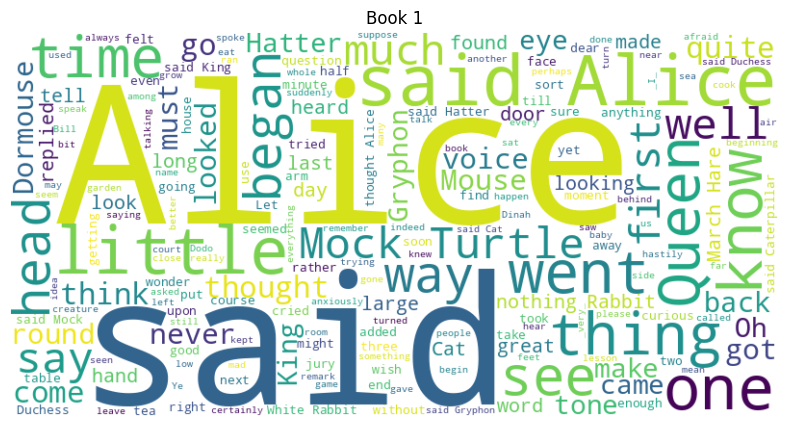

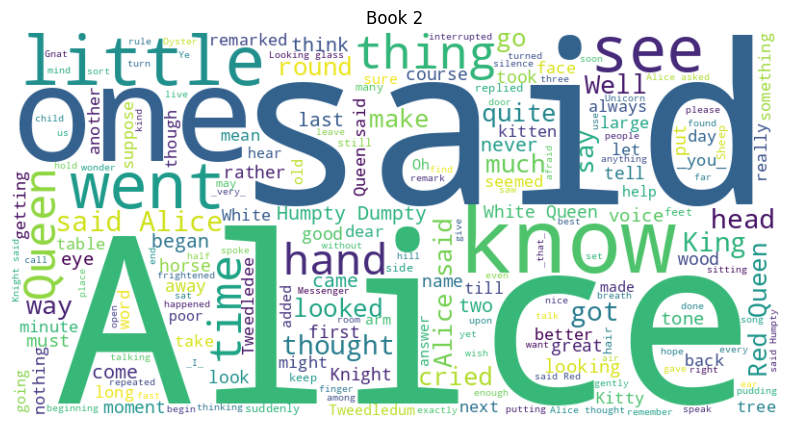

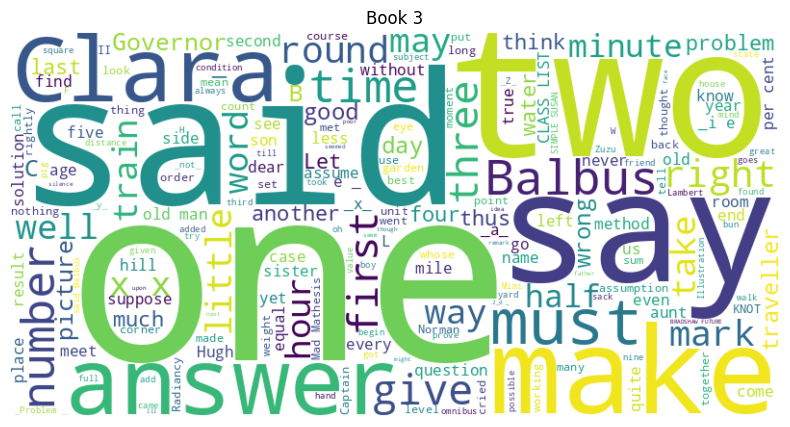

In [18]:
for i, tokens in enumerate(filtered_books):
    text_for_cloud = ' '.join(tokens)     # WordCloud wants a single string
    wc = WordCloud(width=800, height=400, background_color='white').generate(text_for_cloud)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Book {i+1}')
    plt.show()

In [22]:
docs = [' '.join(book) for book in filtered_books]  # one string per book

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(docs)

words  = vectorizer.get_feature_names_out()  # aligned with the columns

# Find the 5 most frequent words for each document
top5_for_chart = [] # Initialize here to store results for the chart
for i, doc_counts in enumerate(X.toarray()):
    word_count_pairs = sorted(list(zip(words, doc_counts)), key=lambda x: x[1], reverse=True)
    print(f'--- Top 5 words for Book {i+1} ---\n')
    for word, count in word_count_pairs[:5]:
        print(f'{word}: {count}')
    print('\n')
    if i == 0: # Store the top 5 words of the first book for the chart
        top5_for_chart = word_count_pairs[:5]


--- Top 5 words for Book 1 ---

said: 460
alice: 396
little: 126
one: 101
know: 87


--- Top 5 words for Book 2 ---

said: 473
alice: 455
queen: 185
one: 152
know: 125


--- Top 5 words for Book 3 ---

one: 196
said: 134
two: 102
old: 92
balbus: 70




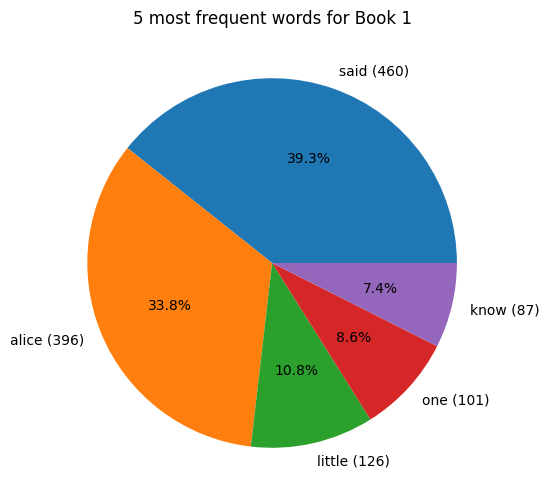

In [23]:
labels = [f'{w} ({c})' for w, c in top5_for_chart]
counts = [c for w, c in top5_for_chart]

plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%')
plt.title('5 most frequent words for Book 1')
plt.show()

These ouputs can be expected from a book about alice with a lot of dialogue (said) as well as 'little one' appearng often. These words are not however particularly insightful as to the context of the book

In [24]:
tfidf = TfidfVectorizer(min_df=1, max_df=2)   # small dataset -> these bounds
M = tfidf.fit_transform(docs)                 # reuse the same `docs` list
words = tfidf.get_feature_names_out()

In [25]:
# TODO for each book row i:
#   row = M[i].toarray().ravel()
#   top_idx = row.argsort()[::-1][:5]        # highest scores first
#   top_words = [(words[j], round(float(row[j]), 3)) for j in top_idx]
#   print(f'Book {i}:', top_words)

top_tfidf_words_per_book = []
for i in range(M.shape[0]):
    row = M[i].toarray().ravel()
    top_idx = row.argsort()[::-1][:5]        # highest scores first
    top_words = [(words[j], round(float(row[j]), 3)) for j in top_idx]
    top_tfidf_words_per_book.append(top_words)
    print(f'Book {i+1}:', top_words)

Book 1: [('gryphon', 0.335), ('rabbit', 0.304), ('turtle', 0.269), ('hatter', 0.259), ('mock', 0.259)]
Book 2: [('dumpty', 0.346), ('humpty', 0.346), ('knight', 0.283), ('tweedledum', 0.222), ('tweedledee', 0.17)]
Book 3: [('balbus', 0.29), ('clara', 0.257), ('_x_', 0.199), ('answers', 0.158), ('_a_', 0.149)]


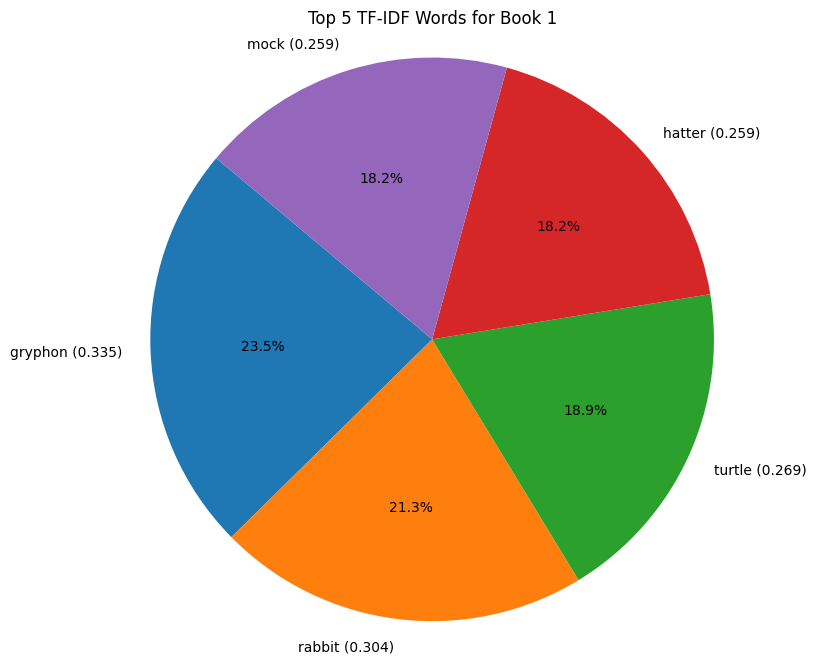

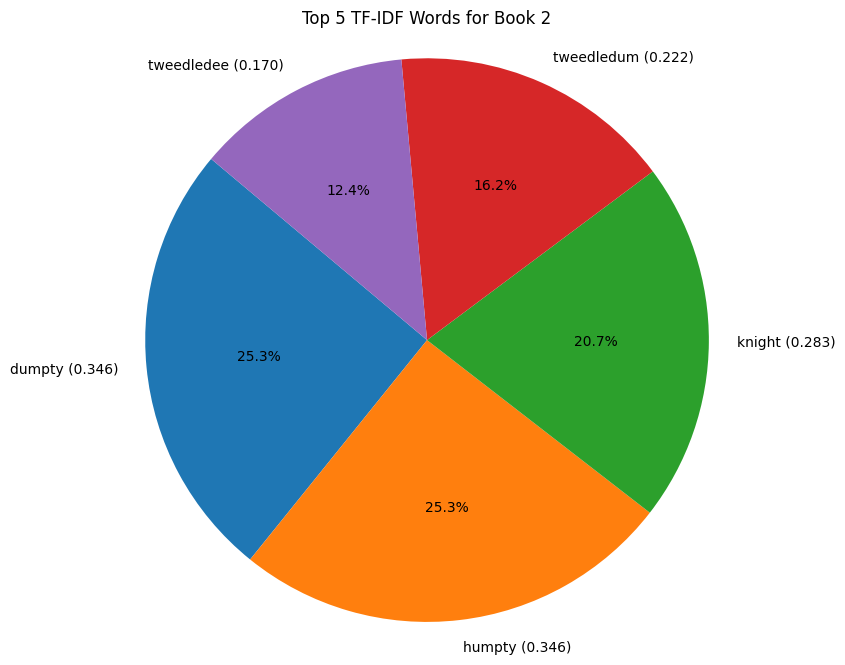

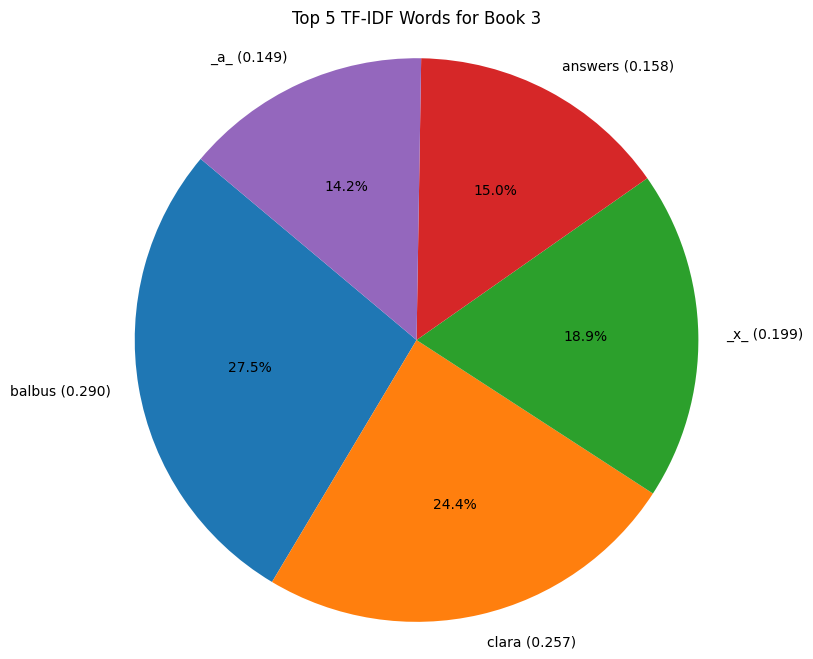

In [26]:
for i, top_words in enumerate(top_tfidf_words_per_book):
    labels = [f'{w} ({s:.3f})' for w, s in top_words]
    scores = [s for w, s in top_words]

    plt.figure(figsize=(8, 8))
    plt.pie(scores, labels=labels, autopct='%1.1f%%', startangle=140)
    plt.title(f'Top 5 TF-IDF Words for Book {i+1}')
    plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()